In [ ]:
# Lab 4 - Spatial and Frequency Filtering

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Upload image

uploaded = files.upload()

image_name = list(uploaded.keys())[0]
img_color = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
print("Color Image Shape: ", img_color.shape)
print("GrayScale Image Shape: ", img_gray.shape)

Saving beautiful-natural-image-1844362_640.jpg to beautiful-natural-image-1844362_640.jpg
Color Image Shape:  (360, 640, 3)
GrayScale Image Shape:  (360, 640)


## Original and Grayscale Image Display

<function matplotlib.pyplot.show(close=None, block=None)>

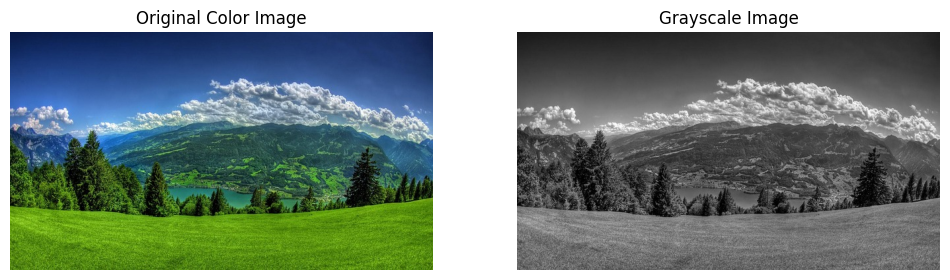

In [ ]:
# Display Original vs Grayscale

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.show

## Gaussian Filter

In [ ]:
# PART 2A - Interactive Mean Filter

def mean_filter(kernel_size):

  #Apply Mean Filter
  blurred = cv2.blur(img_gray, (kernel_size, kernel_size))

  #Show Images Side by Side
  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.imshow(img_gray, cmap='gray')
  plt.title("Original Grayscale Image")
  plt.axis('off')

  plt.subplot(1,2,2)
  plt.imshow(blurred, cmap='gray')
  plt.title(f"Mean Filtered Image (Kernel = {kernel_size}x{kernel_size})")
  plt.axis('off')

  plt.show()

  #Histogram Comparison
  plt.figure(figsize=(10,4))

  plt.subplot(1,2,1)
  plt.hist(img_gray.ravel(), bins = 256)
  plt.title("Original Grayscale Histogram")

  plt.subplot(1,2,2)
  plt.hist(blurred.ravel(), bins = 256)
  plt.title("Blurred Histogram")

  plt.show()

  #Mse Calculation

  ms = np.mean((img_gray - blurred)**2)

  print("MSE between Original and Mean Filtered Image: ", ms)

#Interactive slider
interact(mean_filter, kernel_size = IntSlider(min = 1, max = 21, step = 2, value =3));

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), Output()), _dom_cl…

In [ ]:
def gaussian_filter(kernel_size, sigma):
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), sigma)

    # Show Images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(blurred, cmap='gray')
    plt.title(f"Gaussian (Kernel={kernel_size}, Sigma={sigma})")
    plt.axis('off')

    plt.show()

    # Histogram
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(img_gray.ravel(), bins=256)
    plt.title("Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(blurred.ravel(), bins=256)
    plt.title("Gaussian Histogram")

    plt.show()

    mse = np.mean((img_gray - blurred)**2)
    print("MSE:", mse)

interact(
    gaussian_filter,
    kernel_size=IntSlider(min=1, max=21, step=2, value=3),
    sigma=FloatSlider(min=0.1, max=10, step=0.5, value=1)
)

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), FloatSlider(value=…

<function __main__.gaussian_filter(kernel_size, sigma)>

### Interactive Gaussian Filter

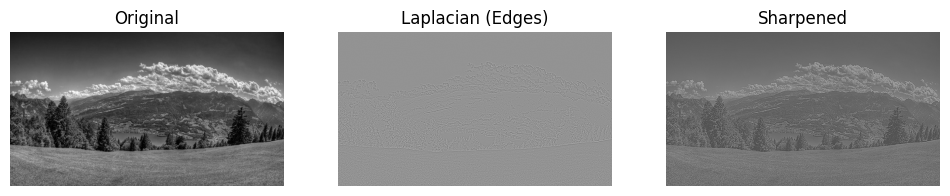

MSE: 2136.951


In [ ]:
# PART 3A - Laplacian Sharpening
# =================================

#Applying laplacian sharpening

def laplacian_sharpen():
    # Apply Laplacian operator
    laplacian = cv2.Laplacian(img_gray, cv2.CV_32F)
    # Sharpened image = Original - Laplacian
    sharpened = img_gray - laplacian

    # Display side-by-
    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(laplacian, cmap='gray')
    plt.title("Laplacian (Edges)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened")
    plt.axis('off')

    plt.show()

    mse = np.mean((img_gray - sharpened)**2)
    print("MSE:", mse)

laplacian_sharpen()

### Laplacian Sharpening Application

In [ ]:
# PART 3: Unsharp Masking
# =============================

from ipywidgets import interact, IntSlider

def unsharp_mask(kernel_size):

    # Blur image
    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), 0)

    # Create mask
    mask = img_gray - blurred

    # Add mask to original
    sharpened = img_gray + mask

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (Edges)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Unsharp Result")
    plt.axis('off')

    plt.show()

interact(unsharp_mask,
         kernel_size=IntSlider(min=1, max=21, step=2, value=3))

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), Output()), _dom_cl…

<function __main__.unsharp_mask(kernel_size)>

### Interactive Unsharp Masking

In [ ]:
#hightboost
def high_boost(kernel_size, k):
    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), 0)
    mask = img_gray - blurred
    highboost = img_gray + k * mask
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(highboost, cmap='gray')
    plt.title(f"High Boost (k={k})")
    plt.axis('off')
    plt.show()
    mse = np.mean((img_gray - highboost)**2)
    print("MSE:", mse)
interact(
     high_boost,
     kernel_size=IntSlider(min=1, max=21, step=2, value=3),
     k=FloatSlider(min=0.1, max=10, step=0.1, value=1.0)
 )

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), FloatSlider(value=…

<function __main__.high_boost(kernel_size, k)>

## High Boost Filtering

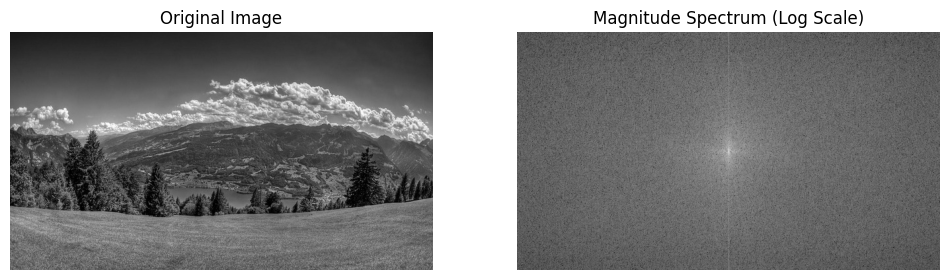

In [ ]:
# PART 4A
# Fourier Transform

# Compute 2D FFT
f = np.fft.fft2(img_gray)
# Shift zero frequency to center
fshift = np.fft.fftshift(f)
# Compute magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
# Display
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum (Log Scale)")
plt.axis('off')
plt.show()

### Fourier Transform and Magnitude Spectrum

In [ ]:
# PART 4B Ideal Low Pass Filter
def ideal_low_pass(radius):
    rows, cols = img_gray.shape
    crow, ccol = rows//2, cols//2

    # Create mask
    mask = np.zeros((rows, cols), np.uint8)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= radius:
                mask[i,j] = 1

    # Apply mask
    fshift_filtered = fshift * mask

    # Inverse FFT
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # Show Results
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("Low Pass Mask")

    plt.imshow(mask, cmap="gray")
    plt.title("Low Pass Mask")
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"Low Pass Output (r={radius})")
    plt.axis('off')
    plt.show()

interact(ideal_low_pass, radius=IntSlider(min=10, max=200, step=10, value=50))

interactive(children=(IntSlider(value=50, description='radius', max=200, min=10, step=10), Output()), _dom_cla…

<function __main__.ideal_low_pass(radius)>

### Ideal Low Pass Filter Implementation

In [ ]:
# PART 4C Ideal High Pass Filter
def ideal_high_pass(radius):
    rows, cols = img_gray.shape
    crow, ccol = rows//2, cols//2

    # Create a mask initialized with ones
    mask = np.ones((rows, cols), np.uint8)
    # Set the central circular region to zero (blocking low frequencies)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= radius:
                mask[i,j] = 0

    # Apply mask to the shifted Fourier transform
    fshift_filtered = fshift * mask

    # Inverse Fourier shift
    f_ishift = np.fft.ifftshift(fshift_filtered)
    # Inverse Fourier transform
    img_back = np.fft.ifft2(f_ishift)
    # Get absolute value for the image
    img_back = np.abs(img_back)

    # Show Results
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("High Pass Mask")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"High Pass Output (r={radius})")
    plt.axis('off')
    plt.show()

interact(ideal_high_pass, radius=IntSlider(min=10, max=200, step=10, value=50))

interactive(children=(IntSlider(value=50, description='radius', max=200, min=10, step=10), Output()), _dom_cla…

<function __main__.ideal_high_pass(radius)>

### Ideal High Pass Filter Implementation

##From Here AIIIIIIII


# Task: Analyze Low-Pass and High-Pass Filters

# Task
Apply ideal low-pass and high-pass filters with a radius of 50 to the `img_gray` image, then compute and visualize the log-magnitude spectrums and histograms of the filtered images to compare their frequency content.

## Apply Ideal Low-Pass and High-Pass Filters

## Apply Low Pass Filter and High Pass Filter

### Subtask:
Apply ideal low-pass and high-pass filters to the grayscale image (`img_gray`) using a chosen radius (e.g., 50). This step will involve replicating the filtering logic from the previously defined functions to obtain the filtered images in both spatial and frequency domains.


### Filtering Logic

**Reasoning**:
The subtask requires applying ideal low-pass and high-pass filters. I will generate a code block that initializes necessary variables, creates the low-pass mask, applies it, performs inverse transformations to get the low-pass filtered image. Then, it will create the high-pass mask, apply it, and perform inverse transformations to get the high-pass filtered image, all according to the given instructions.



In [ ]:
radius = 50
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2

# Ideal Low Pass Filter
low_pass_mask = np.zeros((rows, cols), np.uint8)
for i in range(rows):
    for j in range(cols):
        if np.sqrt((i - crow)**2 + (j - ccol)**2) <= radius:
            low_pass_mask[i, j] = 1

fshift_low_pass_filtered = fshift * low_pass_mask
f_ishift_low_pass = np.fft.ifftshift(fshift_low_pass_filtered)
img_low_pass = np.fft.ifft2(f_ishift_low_pass)
img_low_pass = np.abs(img_low_pass)

# Ideal High Pass Filter
high_pass_mask = np.ones((rows, cols), np.uint8)
for i in range(rows):
    for j in range(cols):
        if np.sqrt((i - crow)**2 + (j - ccol)**2) <= radius:
            high_pass_mask[i, j] = 0

fshift_high_pass_filtered = fshift * high_pass_mask
f_ishift_high_pass = np.fft.ifftshift(fshift_high_pass_filtered)
img_high_pass = np.fft.ifft2(f_ishift_high_pass)
img_high_pass = np.abs(img_high_pass)

print("Ideal Low Pass and High Pass filters applied. Results are stored in img_low_pass and img_high_pass.")

Ideal Low Pass and High Pass filters applied. Results are stored in img_low_pass and img_high_pass.


## Compute and Visualize Log-Magnitude Spectrums

**Reasoning**:
Now that the low-pass and high-pass filtered images are generated, the next step is to compute and visualize their log-magnitude spectrums to analyze their frequency content, as per the main task.



### Spectrums Calculation and Display

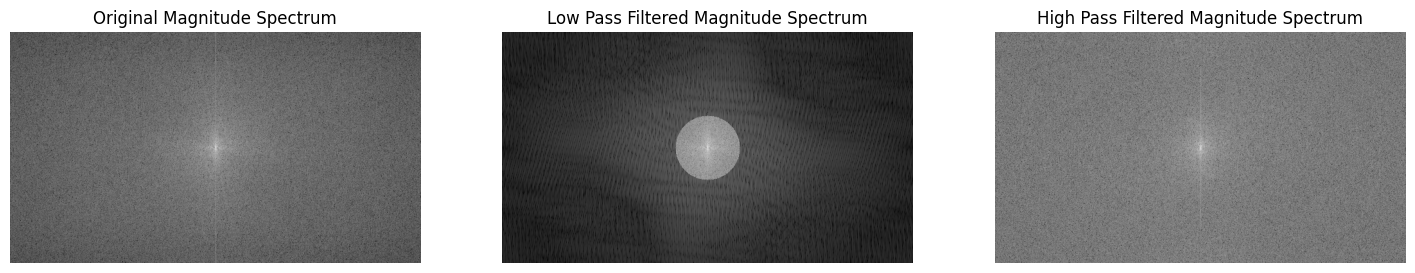

Log-magnitude spectrums of filtered images computed and displayed.


In [ ]:
f_low_pass = np.fft.fft2(img_low_pass)
fshift_low_pass_spectrum = np.fft.fftshift(f_low_pass)
magnitude_spectrum_low_pass = 20 * np.log(np.abs(fshift_low_pass_spectrum) + 1)

f_high_pass = np.fft.fft2(img_high_pass)
fshift_high_pass_spectrum = np.fft.fftshift(f_high_pass)
magnitude_spectrum_high_pass = 20 * np.log(np.abs(fshift_high_pass_spectrum) + 1)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Original Magnitude Spectrum")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum_low_pass, cmap='gray')
plt.title("Low Pass Filtered Magnitude Spectrum")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(magnitude_spectrum_high_pass, cmap='gray')
plt.title("High Pass Filtered Magnitude Spectrum")
plt.axis('off')

plt.show()

print("Log-magnitude spectrums of filtered images computed and displayed.")

## Compute and Visualize Histograms of Filtered Images

**Reasoning**:
The main task requires visualizing histograms of the filtered images. Therefore, the next step is to compute and display the histograms for `img_low_pass` and `img_high_pass`, alongside the original image's histogram, to compare their frequency content in the spatial domain.



### Histograms Calculation and Display

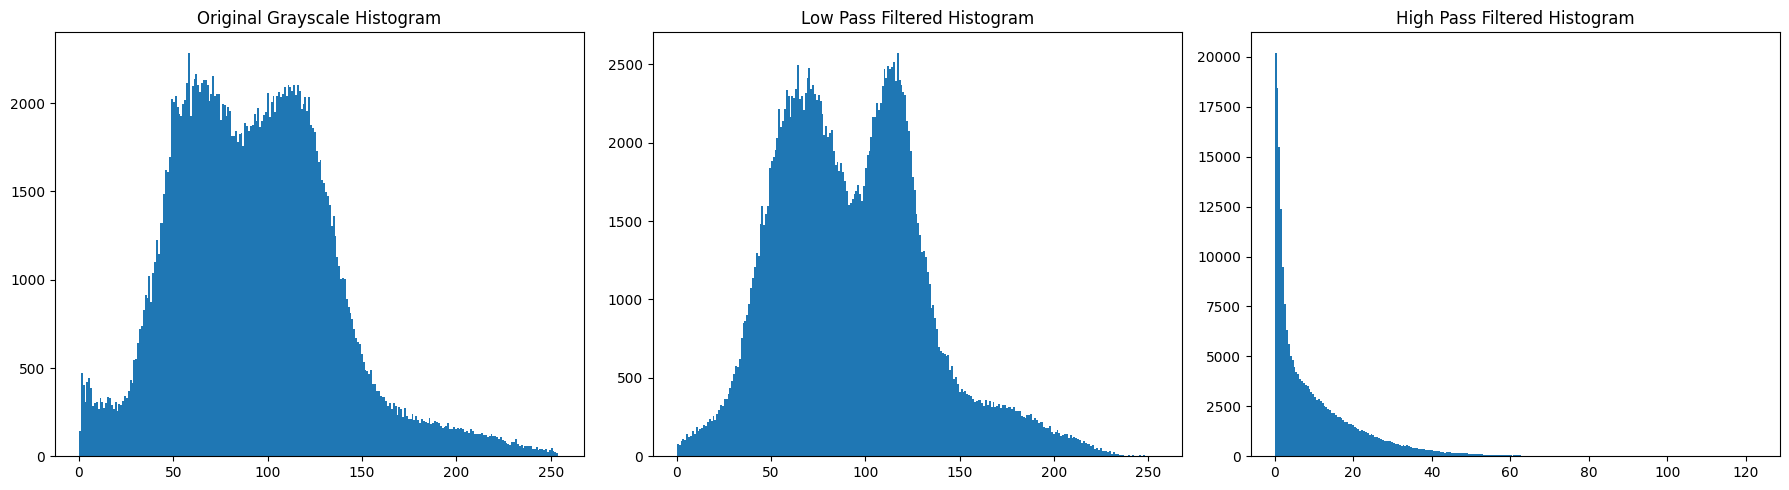

Histograms of filtered images computed and displayed.


In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(img_gray.ravel(), bins=256)
plt.title("Original Grayscale Histogram")

plt.subplot(1, 3, 2)
plt.hist(img_low_pass.ravel(), bins=256)
plt.title("Low Pass Filtered Histogram")

plt.subplot(1, 3, 3)
plt.hist(img_high_pass.ravel(), bins=256)
plt.title("High Pass Filtered Histogram")

plt.tight_layout()
plt.show()

print("Histograms of filtered images computed and displayed.")

## Visualize Filtered Images

## Visualize Filtered Images and Spectrums

### Subtask:
Visualize the low-pass and high-pass filtered images in the spatial domain alongside the original grayscale image to observe the effects of filtering.


### Spatial Domain Visualization

**Reasoning**:
The subtask requires visualizing the original, low-pass, and high-pass filtered images in the spatial domain. This code block will create a figure with three subplots to display these images as instructed, using a grayscale colormap and turning off the axes for better visualization.



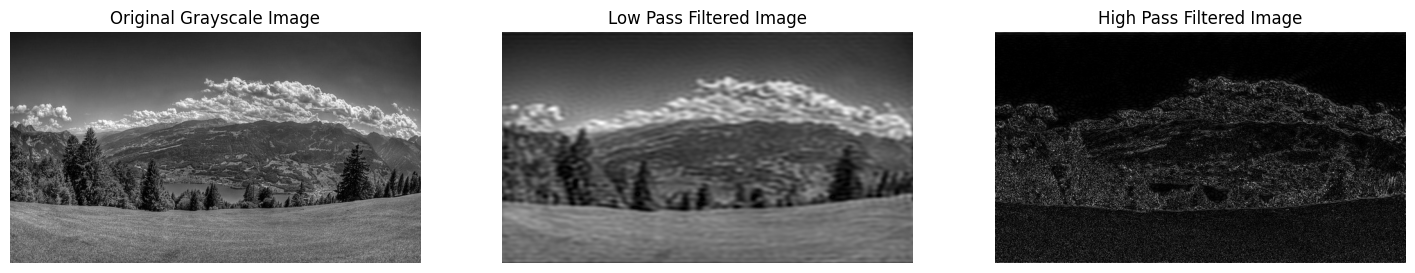

Visualized original, low-pass, and high-pass filtered images.


In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_low_pass, cmap='gray')
plt.title('Low Pass Filtered Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_high_pass, cmap='gray')
plt.title('High Pass Filtered Image')
plt.axis('off')

plt.show()

print("Visualized original, low-pass, and high-pass filtered images.")

## Compare Log-Magnitude Spectrums Histograms

## Compare Magnitude Histograms

### Subtask:
Plot the histograms of the log-magnitude spectrums for both the low-pass and high-pass filtered images on the same graph for a direct comparison of their frequency distributions. Include appropriate titles and legends.


### Histogram Comparison

**Reasoning**:
The subtask requires plotting the histograms of the log-magnitude spectrums for both low-pass and high-pass filtered images on the same graph for direct comparison. I will create a code block to generate this plot with appropriate titles and legends.



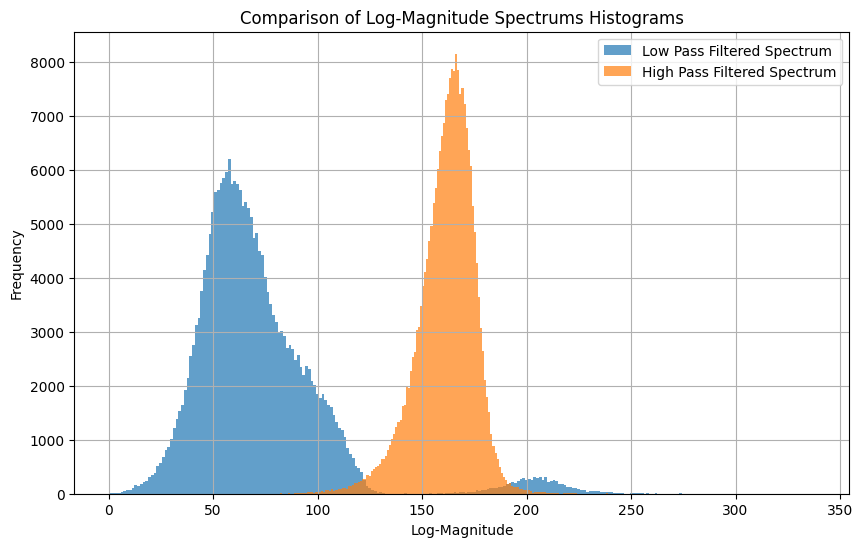

Histograms of log-magnitude spectrums for low-pass and high-pass filtered images plotted.


In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(magnitude_spectrum_low_pass.ravel(), bins=256, alpha=0.7, label='Low Pass Filtered Spectrum')
plt.hist(magnitude_spectrum_high_pass.ravel(), bins=256, alpha=0.7, label='High Pass Filtered Spectrum')

plt.title('Comparison of Log-Magnitude Spectrums Histograms')
plt.xlabel('Log-Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print("Histograms of log-magnitude spectrums for low-pass and high-pass filtered images plotted.")